# ModernBERT-large Gated Hybrid: Training, Evaluation and XAI

**COIT20265 · Md Sadman Sakib (MdSadmanCQU)**

This notebook trains the team's **gated hybrid** architecture with **ModernBERT-large** as the backbone instead of DeBERTa-v3-large. Everything else is kept the same for a fair comparison:

| Kept the same as the DeBERTa hybrid | Value |
|---|---|
| Data split | `phishing_train/validation/test.csv` (14,015 / 1,752 / 1,752) |
| 12 handcrafted features | Same word lists and rules as the Chrome extension |
| Architecture | Context projection → feature projection → gate → fusion → classifier (all 256-d) |
| Training | 3 epochs, lr 1e-5, weight decay 0.01, warmup 263, effective batch 16, seed 42, best model by validation F1 |
| Max length | 512 tokens (same as the DeBERTa hybrid and the extension) |

**Steps:** 1 setup → 2 data → 3 features → 4 tokens → 5 model → 6 quick test → 7 train → 8 test results → 9 save for the extension → 10 reload check → 11 gate and feature analysis → 12 download.

**Runtime:** choose *Runtime → Change runtime type → A100 GPU* (T4 also works but is slower). Run the cells in order.

## Step 1. Setup
Install a recent `transformers` (ModernBERT needs 4.48 or newer), check the GPU, mount Google Drive and fix the random seed.

In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 130.3 MB/s eta 0:00:00


In [ ]:
import os, re, json, random, time, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import transformers
from datasets import Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, TrainingArguments, Trainer, set_seed
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, f1_score)
import matplotlib.pyplot as plt

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
set_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

assert torch.cuda.is_available(), "No GPU. Use Runtime > Change runtime type > GPU."
print("transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

transformers: 5.18.0
PyTorch: 2.11.0+cu130
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ---- Change these two paths if your files are somewhere else ----
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"          # folder with the 3 CSV files
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/modernbert_hybrid_model"   # where the trained model is saved

for f in ["phishing_train.csv", "phishing_validation.csv", "phishing_test.csv"]:
    print(f, "found" if os.path.exists(f"{DATA_DIR}/{f}") else "MISSING")

Mounted at /content/drive
phishing_train.csv found
phishing_validation.csv found
phishing_test.csv found


## Step 2. Load the data
The same frozen 80/10/10 split used by every model in the project.

In [ ]:
train_df = pd.read_csv(f"{DATA_DIR}/phishing_train.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/phishing_validation.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/phishing_test.csv")

for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:11s} {df.shape}  labels: {df['label'].value_counts().sort_index().to_dict()}")

assert len(train_df) == 14015 and len(val_df) == 1752 and len(test_df) == 1752, "Unexpected split sizes"
TEXT = 'processed_text'

Train       (14015, 4)  labels: {0: 8782, 1: 5233}
Validation  (1752, 4)  labels: {0: 1098, 1: 654}
Test        (1752, 4)  labels: {0: 1098, 1: 654}


## Step 3. The 12 handcrafted features
This is **the exact same function** as `chrome_extension/predictor.py`, so the features seen in training match what the extension computes later. The mean and standard deviation come from the **training set only**.

In [ ]:
URGENCY_TERMS = ["urgent", "urgently", "immediately", "immediate", "now",
                 "today", "asap", "quickly", "deadline", "expire", "expired", "final", "action"]
CREDENTIAL_TERMS = ["password", "passwd", "username", "login", "credential", "credentials",
                    "verify", "verification", "authenticate", "authentication", "account"]
THREAT_TERMS = ["suspend", "suspended", "terminate", "terminated", "blocked", "block", "close",
                "closed", "penalty", "fraud", "unauthorized", "warning", "security"]
FINANCIAL_TERMS = ["payment", "pay", "invoice", "money", "bank", "transfer", "transaction",
                   "refund", "credit", "debit", "fee", "account", "billing"]
CTA_TERMS = ["click", "clicking", "visit", "open", "download", "confirm", "verify",
             "submit", "update", "activate", "login"]

FEATURE_NAMES = ["urgency_term_count", "credential_term_count", "threat_term_count",
                 "financial_term_count", "cta_term_count", "url_count", "email_count",
                 "phone_count", "exclamation_count", "question_count",
                 "uppercase_word_ratio", "log_text_length"]

def extract_nlp_features(text):
    text = str(text)
    words = re.findall(r"\b\w+\b", text.lower())
    urgency_count = sum(word in URGENCY_TERMS for word in words)
    credential_count = sum(word in CREDENTIAL_TERMS for word in words)
    threat_count = sum(word in THREAT_TERMS for word in words)
    financial_count = sum(word in FINANCIAL_TERMS for word in words)
    cta_count = sum(word in CTA_TERMS for word in words)
    url_count = len(re.findall(r"https?://\S+|www\.\S+", text, flags=re.IGNORECASE))
    email_count = len(re.findall(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", text))
    phone_count = len(re.findall(r"\b(?:\+?\d[\d\s().-]{7,}\d)\b", text))
    exclamation_count = text.count("!")
    question_count = text.count("?")
    all_words = re.findall(r"\b[A-Za-z]+\b", text)
    uppercase_ratio = (sum(w.isupper() and len(w) > 1 for w in all_words) / len(all_words)
                       if all_words else 0.0)
    log_text_length = np.log1p(len(text))
    return [urgency_count, credential_count, threat_count, financial_count, cta_count,
            url_count, email_count, phone_count, exclamation_count, question_count,
            uppercase_ratio, log_text_length]

def features_of(df):
    return np.array([extract_nlp_features(t) for t in df[TEXT]], dtype=np.float32)

train_raw, val_raw, test_raw = features_of(train_df), features_of(val_df), features_of(test_df)

feature_mean = train_raw.mean(axis=0)
feature_std = train_raw.std(axis=0)
feature_std[feature_std == 0] = 1.0

train_feat = (train_raw - feature_mean) / feature_std
val_feat   = (val_raw   - feature_mean) / feature_std
test_feat  = (test_raw  - feature_mean) / feature_std

print("Feature shape:", train_feat.shape)
print(pd.DataFrame({"feature": FEATURE_NAMES, "train_mean": feature_mean.round(3), "train_std": feature_std.round(3)}))

Feature shape: (14015, 12)
                  feature  train_mean   train_std
0      urgency_term_count       1.157   41.636002
1   credential_term_count       0.224    7.011000
2       threat_term_count       0.268    4.825000
3    financial_term_count       1.297   47.112999
4          cta_term_count       0.765   20.237000
5               url_count       0.804   26.607000
6             email_count       0.297    0.966000
7             phone_count       1.557   79.897003
8       exclamation_count       2.659  118.238998
9          question_count       2.109   58.074001
10   uppercase_word_ratio       0.011    0.041000
11        log_text_length       6.819    1.155000


## Step 4. Tokenise with ModernBERT
`max_length=512` matches the DeBERTa hybrid and the extension. (The ModernBERT *baseline* notebook used 8,192; using 512 here keeps the hybrid comparison fair and lets the extension run it.)

In [ ]:
MODEL_NAME = "answerdotai/ModernBERT-large"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(df, feats):
    ds = Dataset.from_dict({
        TEXT: df[TEXT].astype(str).tolist(),
        "labels": df["label"].astype(int).tolist(),
        "nlp_features": feats.tolist(),
    })
    return ds.map(lambda b: tokenizer(b[TEXT], truncation=True, max_length=MAX_LENGTH),
                  batched=True, remove_columns=[TEXT])

train_ds = make_dataset(train_df, train_feat)
val_ds   = make_dataset(val_df, val_feat)
test_ds  = make_dataset(test_df, test_feat)
print(train_ds)

lengths = [len(x) for x in train_ds["input_ids"]]
print(f"Emails longer than {MAX_LENGTH} tokens: {np.mean(np.array(lengths) >= MAX_LENGTH):.1%}")

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Map:   0%|          | 0/14015 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'nlp_features', 'input_ids', 'attention_mask'],
    num_rows: 14015
})
Emails longer than 512 tokens: 23.5%


In [ ]:
def collate(batch):
    """Pad tokens to the longest email in the batch; stack features and labels."""
    tokens = tokenizer.pad(
        [{"input_ids": b["input_ids"], "attention_mask": b["attention_mask"]} for b in batch],
        return_tensors="pt")
    return {
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "nlp_features": torch.tensor([b["nlp_features"] for b in batch], dtype=torch.float32),
        "labels": torch.tensor([b["labels"] for b in batch], dtype=torch.long),
    }

## Step 5. The gated hybrid model
The layer names (`transformer`, `context_projection`, `feature_projection`, `gate`, `fusion`, `classifier`) are **identical** to the DeBERTa hybrid and to `GatedHybridPhishingModel` in the extension. That is what lets the extension load this model with `strict=True` later, with no code changes.

In [ ]:
class GatedHybridPhishingModel(nn.Module):
    def __init__(self, model_name, num_features=12, num_labels=2):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name, dtype=torch.float32)
        hidden = self.transformer.config.hidden_size
        self.context_projection = nn.Sequential(nn.Linear(hidden, 256), nn.ReLU(), nn.Dropout(0.2))
        self.feature_projection = nn.Sequential(nn.Linear(num_features, 256), nn.ReLU(), nn.Dropout(0.2))
        self.gate = nn.Sequential(nn.Linear(512, 256), nn.Sigmoid())
        self.fusion = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.3))
        self.classifier = nn.Linear(256, num_labels)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids=None, attention_mask=None, nlp_features=None, labels=None, **kwargs):
        out = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        context = self.context_projection(out.last_hidden_state[:, 0, :])    # [CLS] token
        features = self.feature_projection(nlp_features.float())
        gate = self.gate(torch.cat([context, features], dim=1))
        fused = gate * context + (1 - gate) * features
        logits = self.classifier(self.fusion(fused))
        loss = self.loss_fn(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}

model = GatedHybridPhishingModel(MODEL_NAME)
model.transformer.gradient_checkpointing_enable()     # saves GPU memory
print("Backbone:", MODEL_NAME, "| hidden size:", model.transformer.config.hidden_size)
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f} M")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.58GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Backbone: answerdotai/ModernBERT-large | hidden size: 1024
Parameters: 395.2 M


## Step 6. Quick test before the long training
One forward and backward pass on 4 emails. If this fails, fix it now instead of after an hour of training.

In [ ]:
model.cuda().train()
batch = {k: v.cuda() for k, v in collate([train_ds[i] for i in range(4)]).items()}
out = model(**batch)
out["loss"].backward()
model.zero_grad(set_to_none=True)
print("Logits shape:", tuple(out["logits"].shape), "| loss:", round(out["loss"].item(), 4))
print("Forward and backward pass OK.")
model.cpu(); torch.cuda.empty_cache()

Logits shape: (4, 2) | loss: 0.6905
Forward and backward pass OK.


## Step 7. Train
Same settings as the DeBERTa hybrid. The best epoch is chosen by **validation F1**. Checkpoints go to local disk (`/content`), not Drive, so training is not slowed down.

Expected time: roughly 1–2 hours on an A100, longer on a T4. Keep the browser tab open.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", pos_label=1, zero_division=0)
    return {"accuracy": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f1}

training_args = TrainingArguments(
    output_dir="/content/modernbert_hybrid_results",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,          # effective batch size 16
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=263,
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=False, bf16=False,                 # full precision, same as the DeBERTa hybrid
    optim="adamw_torch",
    seed=SEED, data_seed=SEED,
    remove_unused_columns=False,
    label_names=["labels"],
    report_to="none",
    save_total_limit=2,
)

trainer = Trainer(model=model, args=training_args, train_dataset=train_ds, eval_dataset=val_ds,
                  data_collator=collate, compute_metrics=compute_metrics)

start = time.time()
train_result = trainer.train()
print(f"Training time: {(time.time() - start)/60:.1f} minutes")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.967181,0.144411,0.973744,0.948378,0.983180,0.965465
2,0.324388,0.075364,0.986872,0.977307,0.987768,0.982510
3,0.093293,0.068247,0.989726,0.986239,0.986239,0.986239


Training time: 65.9 minutes


In [ ]:
history = pd.DataFrame([h for h in trainer.state.log_history if "eval_f1" in h])
print(history[["epoch", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]].round(4).to_string(index=False))

 epoch  eval_loss  eval_accuracy  eval_precision  eval_recall  eval_f1
   1.0     0.1444         0.9737          0.9484       0.9832   0.9655
   2.0     0.0754         0.9869          0.9773       0.9878   0.9825
   3.0     0.0682         0.9897          0.9862       0.9862   0.9862


## Step 8. Test set results
The 1,752 test emails were never used for training or for picking the best epoch.

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.093293,0.066823,3,0.991438,0.983359,0.993884,0.988593


{'test_loss': 0.066823, 'test_accuracy': 0.991438, 'test_precision': 0.983359, 'test_recall': 0.993884, 'test_f1': 0.988593}

                precision    recall  f1-score   support

    Safe Email     0.9963    0.9900    0.9931      1098
Phishing Email     0.9834    0.9939    0.9886       654

      accuracy                         0.9914      1752
     macro avg     0.9898    0.9919    0.9909      1752
  weighted avg     0.9915    0.9914    0.9914      1752

Confusion matrix:
 [[1087   11]
 [   4  650]]


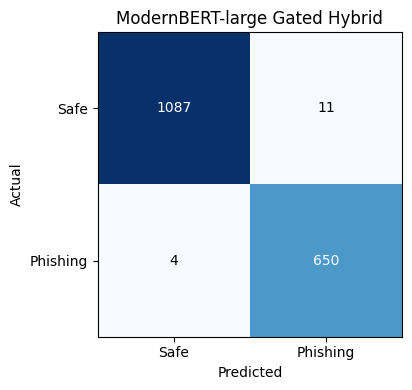

In [ ]:
test_results = trainer.evaluate(test_ds, metric_key_prefix="test")
pred = trainer.predict(test_ds)
test_logits = pred.predictions[0] if isinstance(pred.predictions, (tuple, list)) else pred.predictions
y_pred = test_logits.argmax(axis=1)
y_true = pred.label_ids
cm = confusion_matrix(y_true, y_pred)

print({k: round(v, 6) for k, v in test_results.items() if isinstance(v, float)})
print()
print(classification_report(y_true, y_pred, target_names=["Safe Email", "Phishing Email"], digits=4))
print("Confusion matrix:\n", cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("ModernBERT-large Gated Hybrid")
plt.xticks([0, 1], ["Safe", "Phishing"]); plt.yticks([0, 1], ["Safe", "Phishing"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.savefig("/content/modernbert_hybrid_confusion_matrix.png", dpi=200); plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()
comparison = pd.DataFrame([
    ["DeBERTa-v3-large (baseline)",        0.993721, 0.989346, 0.993884, 0.991609, 7, 4],
    ["DeBERTa-v3-large gated hybrid",      0.994863, 0.996918, 0.989297, 0.993093, 2, 7],
    ["ModernBERT-large (baseline, 8192)",  0.993721, 0.989346, 0.993884, 0.991609, 7, 4],
    ["ModernBERT-large gated hybrid (this run)", test_results["test_accuracy"], test_results["test_precision"],
     test_results["test_recall"], test_results["test_f1"], int(fp), int(fn)],
], columns=["Model", "Accuracy", "Precision", "Recall", "F1", "FP", "FN"])
comparison[["Accuracy", "Precision", "Recall", "F1"]] = (comparison[["Accuracy", "Precision", "Recall", "F1"]] * 100).round(2)
print(comparison.to_string(index=False))
comparison.to_csv("/content/model_comparison.csv", index=False)

                                   Model  Accuracy  Precision  Recall    F1  FP  FN
             DeBERTa-v3-large (baseline)     99.37      98.93   99.39 99.16   7   4
           DeBERTa-v3-large gated hybrid     99.49      99.69   98.93 99.31   2   7
       ModernBERT-large (baseline, 8192)     99.37      98.93   99.39 99.16   7   4
ModernBERT-large gated hybrid (this run)     99.14      98.34   99.39 98.86  11   4


## Step 9. Save in the Chrome extension's format
The extension's `predictor.py` expects exactly these files in `chrome_extension/model/`:

| File | What it is |
|---|---|
| `pytorch_model.bin` | All trained weights (backbone + gate + classifier) |
| `config.json` | ModernBERT architecture settings |
| tokenizer files | ModernBERT tokenizer |
| `feature_mean.npy`, `feature_std.npy` | Training feature scaling |
| `feature_names.json` | Names of the 12 features |
| `model_config.json`, `test_results.json` | Description and test scores |

In [ ]:
best = trainer.model
best.cpu().eval()
os.makedirs(SAVE_DIR, exist_ok=True)

state = {k: v.contiguous() for k, v in best.state_dict().items()}
torch.save(state, f"{SAVE_DIR}/pytorch_model.bin")
best.transformer.config.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
np.save(f"{SAVE_DIR}/feature_mean.npy", feature_mean.astype(np.float32))
np.save(f"{SAVE_DIR}/feature_std.npy", feature_std.astype(np.float32))
json.dump(FEATURE_NAMES, open(f"{SAVE_DIR}/feature_names.json", "w"), indent=2)
json.dump({
    "model_name": MODEL_NAME,
    "num_features": 12, "num_labels": 2, "max_length": MAX_LENGTH,
    "context_dimension": best.transformer.config.hidden_size,
    "context_projection_dimension": 256, "feature_projection_dimension": 256, "fusion_dimension": 256,
    "architecture": "ModernBERT-large + 12 NLP features + gated fusion",
    "random_seed": SEED,
}, open(f"{SAVE_DIR}/model_config.json", "w"), indent=2)
json.dump({"test_results": {k: v for k, v in test_results.items() if isinstance(v, float)},
           "confusion_matrix": cm.tolist()}, open(f"{SAVE_DIR}/test_results.json", "w"), indent=2)

for f in sorted(os.listdir(SAVE_DIR)):
    print(f"{f:28s} {os.path.getsize(f'{SAVE_DIR}/{f}')/1e6:9.1f} MB")

config.json                        0.0 MB
feature_mean.npy                   0.0 MB
feature_names.json                 0.0 MB
feature_std.npy                    0.0 MB
model_config.json                  0.0 MB
pytorch_model.bin               1581.0 MB
test_results.json                  0.0 MB
tokenizer.json                     3.6 MB
tokenizer_config.json              0.0 MB


## Step 10. Reload check (exactly like the extension does)
Build an **empty** model from the saved `config.json`, load the saved weights with `strict=True`, and check that it gives the same predictions. If this passes, the extension will load it.

In [ ]:
class ExtensionStyleModel(nn.Module):
    """Same structure as GatedHybridPhishingModel in chrome_extension/predictor.py."""
    def __init__(self, cfg):
        super().__init__()
        self.transformer = AutoModel.from_config(cfg)
        self.context_projection = nn.Sequential(nn.Linear(cfg.hidden_size, 256), nn.ReLU(), nn.Dropout(0.2))
        self.feature_projection = nn.Sequential(nn.Linear(12, 256), nn.ReLU(), nn.Dropout(0.2))
        self.gate = nn.Sequential(nn.Linear(512, 256), nn.Sigmoid())
        self.fusion = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.3))
        self.classifier = nn.Linear(256, 2)
    def forward(self, input_ids, attention_mask, nlp_features):
        out = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        context = self.context_projection(out.last_hidden_state[:, 0, :])
        features = self.feature_projection(nlp_features.float())
        gate = self.gate(torch.cat([context, features], dim=1))
        return self.classifier(self.fusion(gate * context + (1 - gate) * features))

cfg = AutoConfig.from_pretrained(SAVE_DIR)
reloaded = ExtensionStyleModel(cfg)
reloaded.load_state_dict(torch.load(f"{SAVE_DIR}/pytorch_model.bin", map_location="cpu", weights_only=True), strict=True)
reloaded.cuda().eval()
print("strict=True load OK")

check = [test_ds[i] for i in range(64)]
with torch.no_grad():
    preds = []
    for i in range(0, 64, 16):
        b = {k: v.cuda() for k, v in collate(check[i:i+16]).items()}
        preds.append(reloaded(b["input_ids"], b["attention_mask"], b["nlp_features"]).argmax(1).cpu())
match = (torch.cat(preds).numpy() == y_pred[:64]).mean()
print(f"Same predictions as the trained model on 64 test emails: {match:.0%}")
del reloaded; torch.cuda.empty_cache()

## Step 11. Gate and feature analysis (XAI)
The same analysis I ran on the DeBERTa hybrid. It answers: **does ModernBERT use the 12 handcrafted features, or ignore them like DeBERTa did?**

ModernBERT is run once per test email and its output cached, so all the experiments below take seconds.

In [ ]:
best.cuda().eval()

@torch.no_grad()
def cache_test_set(batch_size=16):
    cls_list = []
    for i in range(0, len(test_ds), batch_size):
        b = collate([test_ds[j] for j in range(i, min(i + batch_size, len(test_ds)))])
        out = best.transformer(input_ids=b["input_ids"].cuda(), attention_mask=b["attention_mask"].cuda())
        cls_list.append(out.last_hidden_state[:, 0, :].float().cpu())
    return torch.cat(cls_list)

cls_emb = cache_test_set()
norm_feats = torch.tensor(test_feat, dtype=torch.float32)
y_true_np = test_df["label"].values

@torch.no_grad()
def head(cls, feats, gate_override=None):
    context = best.context_projection(cls.cuda())
    features = best.feature_projection(feats.cuda())
    gate = best.gate(torch.cat([context, features], dim=1))
    if gate_override is not None:
        gate = torch.full_like(gate, float(gate_override))
    logits = best.classifier(best.fusion(gate * context + (1 - gate) * features))
    return torch.softmax(logits, 1)[:, 1].cpu().numpy(), logits.argmax(1).cpu().numpy(), gate.mean(1).cpu().numpy()

def metrics(pred):
    tn, fp, fn, tp = confusion_matrix(y_true_np, pred, labels=[0, 1]).ravel()
    return {"accuracy %": round(accuracy_score(y_true_np, pred) * 100, 2),
            "f1 %": round(f1_score(y_true_np, pred) * 100, 2), "FP": int(fp), "FN": int(fn)}

base_prob, base_pred, base_gate = head(cls_emb, norm_feats)
print("Sanity check, cached pipeline vs trainer:", metrics(base_pred), "| agreement:", f"{(base_pred == y_pred).mean():.2%}")

Sanity check, cached pipeline vs trainer: {'accuracy %': 99.14, 'f1 %': 98.86, 'FP': 11, 'FN': 4} | agreement: 100.00%


In [ ]:
# Gate values
gate_df = pd.DataFrame({"true": y_true_np, "pred": base_pred, "gate": base_gate})
gate_df["group"] = np.select(
    [(gate_df.true == 1) & (gate_df.pred == 1), (gate_df.true == 0) & (gate_df.pred == 0),
     (gate_df.true == 1) & (gate_df.pred == 0)],
    ["Correct - Phishing", "Correct - Safe", "False Negative"], "False Positive")
print(f"Mean gate (share of trust on the text): {base_gate.mean():.3f} ± {base_gate.std():.3f}"
      f"  (range {base_gate.min():.3f}–{base_gate.max():.3f})\n")
print(gate_df.groupby("group")["gate"].agg(["count", "mean", "std", "min", "max"]).round(3))

# Branch ablation
rows = [{"setting": "Learned gate (model)", **metrics(base_pred)}]
rows.append({"setting": "Text only (gate = 1)", **metrics(head(cls_emb, norm_feats, 1.0)[1])})
rows.append({"setting": "Features only (gate = 0)", **metrics(head(cls_emb, norm_feats, 0.0)[1])})
rows.append({"setting": "Features at training mean", **metrics(head(cls_emb, torch.zeros_like(norm_feats))[1])})
branch_df = pd.DataFrame(rows)
print("\n", branch_df.to_string(index=False))

Mean gate (share of trust on the text): 0.616 ± 0.003  (range 0.595–0.654)

                    count   mean    std    min    max
group                                                
Correct - Phishing    650  0.617  0.004  0.602  0.654
Correct - Safe       1087  0.616  0.002  0.602  0.632
False Negative          4  0.612  0.002  0.610  0.615
False Positive         11  0.609  0.010  0.595  0.631

                   setting  accuracy %  f1 %  FP  FN
     Learned gate (model)       99.14 98.86  11   4
     Text only (gate = 1)       99.14 98.86  11   4
 Features only (gate = 0)       59.99 16.84 118 583
Features at training mean       99.14 98.86  11   4


              feature  accuracy_drop_pp  mean_abs_prob_change
          email_count               0.0          3.760715e-06
      log_text_length               0.0          1.598574e-06
 uppercase_word_ratio               0.0          1.417589e-06
    threat_term_count               0.0          2.170173e-07
       cta_term_count               0.0          1.856466e-07
            url_count               0.0          1.500980e-07
       question_count               0.0          1.240424e-07
 financial_term_count               0.0          7.400831e-08
   urgency_term_count               0.0          5.492474e-08
          phone_count               0.0          3.189584e-08
    exclamation_count               0.0          3.098711e-08
credential_term_count               0.0          2.568406e-08


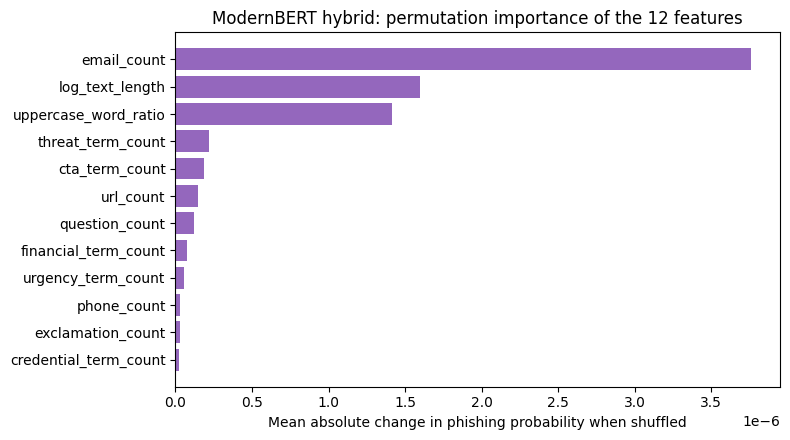

In [ ]:
# Permutation importance of each feature (10 shuffles)
rng = np.random.default_rng(SEED)
perm_rows = []
for j, name in enumerate(FEATURE_NAMES):
    acc_drop, prob_change = [], []
    for _ in range(10):
        shuffled = norm_feats.clone()
        shuffled[:, j] = norm_feats[torch.as_tensor(rng.permutation(len(shuffled))), j]
        p, pr, _ = head(cls_emb, shuffled)
        acc_drop.append(accuracy_score(y_true_np, base_pred) - accuracy_score(y_true_np, pr))
        prob_change.append(np.abs(p - base_prob).mean())
    perm_rows.append({"feature": name, "accuracy_drop_pp": np.mean(acc_drop) * 100,
                      "mean_abs_prob_change": np.mean(prob_change)})
perm_df = pd.DataFrame(perm_rows).sort_values("mean_abs_prob_change", ascending=False)
print(perm_df.to_string(index=False))

plt.figure(figsize=(8, 4.5))
plt.barh(perm_df.feature[::-1], perm_df.mean_abs_prob_change[::-1], color="tab:purple")
plt.xlabel("Mean absolute change in phishing probability when shuffled")
plt.title("ModernBERT hybrid: permutation importance of the 12 features")
plt.tight_layout(); plt.savefig("/content/modernbert_feature_importance.png", dpi=200); plt.show()

gate_df.to_csv("/content/modernbert_gate_values.csv", index=False)
branch_df.to_csv("/content/modernbert_branch_ablation.csv", index=False)
perm_df.to_csv("/content/modernbert_permutation_importance.csv", index=False)

**How to read Step 11**
- If *Text only* gives the same accuracy as the full model, and permutation importance is near zero, then ModernBERT also ignores the 12 features, the same as DeBERTa.
- If *Text only* is worse, or some features have clear importance, then ModernBERT actually uses the features. That would be a new finding worth reporting.

## Step 12. Copy the results to Drive and download
The model folder is already in Drive (Step 9). This copies the result tables and charts next to it, and zips the model for download to the laptop.

In [ ]:
RESULTS_DIR = f"{SAVE_DIR}_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
for f in ["model_comparison.csv", "modernbert_hybrid_confusion_matrix.png", "modernbert_gate_values.csv",
          "modernbert_branch_ablation.csv", "modernbert_permutation_importance.csv",
          "modernbert_feature_importance.png"]:
    shutil.copy(f"/content/{f}", RESULTS_DIR)
print("Results copied to:", RESULTS_DIR)

shutil.make_archive("/content/modernbert_hybrid_model", "zip", SAVE_DIR)
print(f"Zip: /content/modernbert_hybrid_model.zip ({os.path.getsize('/content/modernbert_hybrid_model.zip')/1e9:.2f} GB)")
print("Download it from Drive (faster) or the Colab file panel.")

Results copied to: /content/drive/MyDrive/Colab Notebooks/modernbert_hybrid_model_results
Zip: /content/modernbert_hybrid_model.zip (1.47 GB)
Download it from Drive (faster) or the Colab file panel.
